# 1. Business Problem

The goal of this project is to build a binary classification model
that predicts whether a breast tumor is malignant or benign based
on measured characteristics of the tumor cells.

The main objective is not only to maximize predictive performance,
but also to understand the model's errors and evaluate which metrics
are most appropriate for the business/medical context.

# 2. Dataset Loading

In [3]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [4]:
project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from ml_from_scratch.linear_models.logistic_regression import LogisticRegression
from ml_from_scratch.preprocessing.scaler import MyStandardScaler

from ml_from_scratch.metrics.classification import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    log_loss
)

In [5]:
data = load_breast_cancer()

X = data.data
y = data.target

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Classes:', data.target_names)

X shape: (569, 30)
y shape: (569,)
Classes: ['malignant' 'benign']


In [6]:
df = pd.DataFrame(X, columns = data.feature_names)
df['target'] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# 3. Data Validation

In [7]:
print(f'No. Samples: {X.shape[0]}')
print(f'No. features: {X.shape[1]}')

No. Samples: 569
No. features: 30


In [8]:
print('Data type:\n')
print(X.dtype)

Data type:

float64


In [10]:
print(f'Missing values: {np.isnan(X).sum()}')

Missing values: 0


In [11]:
print(f'Target values: {np.unique(y)}')
print(f'Target counts: {np.bincount(y)}')

Target values: [0 1]
Target counts: [212 357]


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [14]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [15]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


# 4. Target Analysis

In [ ]:
class_count = pd.Series(y).value_counts()
print(class_count)

1    357
0    212
Name: count, dtype: int64


In [21]:
print(class_count / len(y))

1    0.627417
0    0.372583
Name: count, dtype: float64


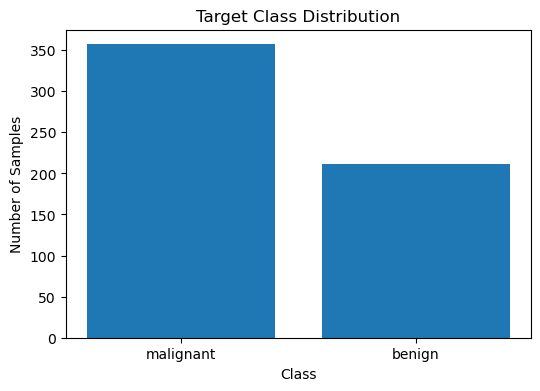

In [ ]:
plt.figure(figsize = (6, 4))

plt.bar(data.target_names, class_count.values)

plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')

plt.show()

# 5. Feature Analysis

C:\Users\B2B\AppData\Local\Temp\ipykernel_20284\3267434033.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(X, labels = data.feature_names, vert = False)


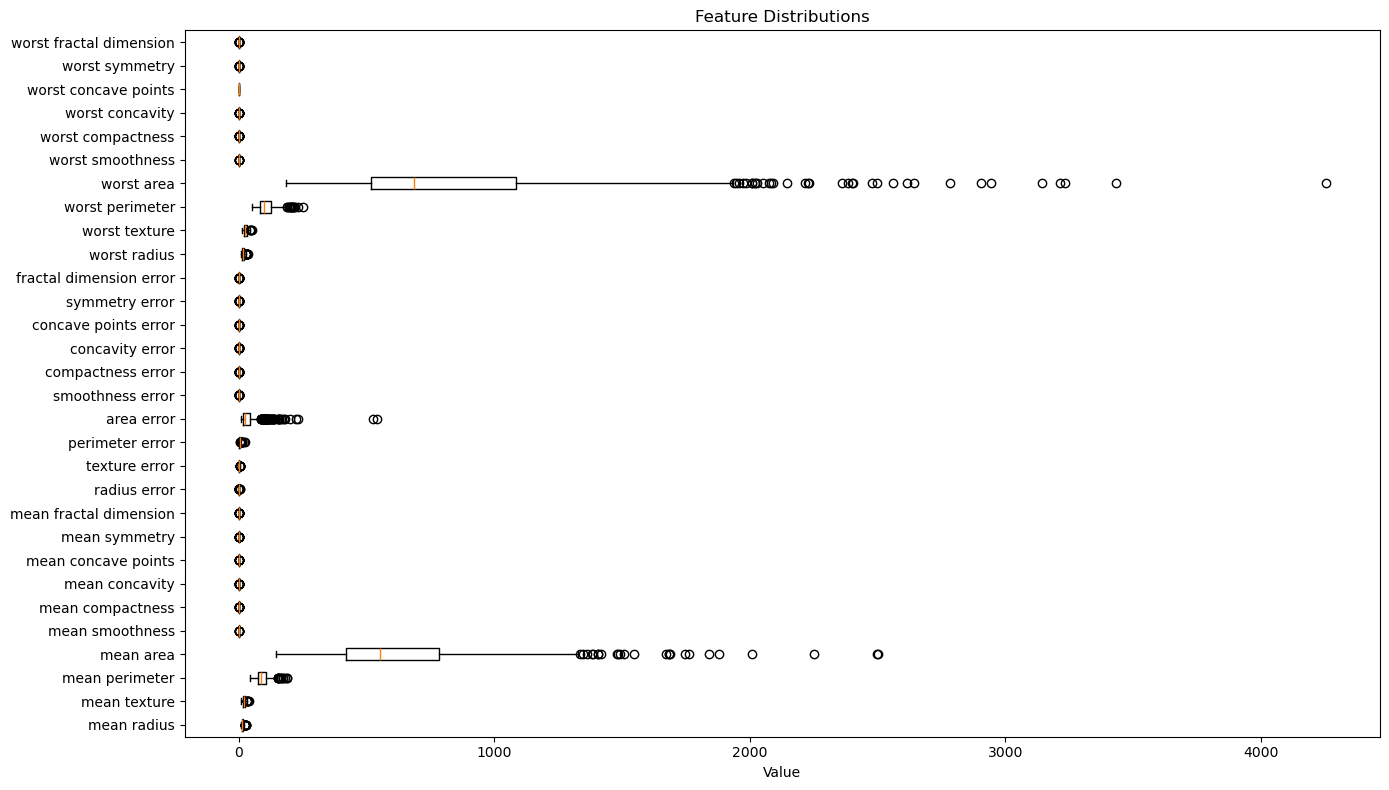

In [23]:
plt.figure(figsize = (14, 8))

plt.boxplot(X, labels = data.feature_names, vert = False)

plt.title('Feature Distributions')
plt.xlabel('Value')

plt.tight_layout()
plt.show()

# 6. Check Feature Scale

In [29]:
feature_stats = pd.DataFrame({
    'min': X.min(axis = 0),
    'mean': X.mean(axis = 0),
    'std': X.std(axis = 0),
    'max': X.max(axis = 0),
}, index = data.feature_names)

feature_stats.sort_values('std', ascending = False).T

,worst area,mean area,area error,worst perimeter,mean perimeter,worst texture,worst radius,mean texture,mean radius,perimeter error,...,mean symmetry,worst smoothness,worst fractal dimension,compactness error,mean smoothness,symmetry error,mean fractal dimension,concave points error,smoothness error,fractal dimension error
min,185.200000,143.500000,6.802000,50.410000,43.790000,12.020000,7.930000,9.710000,6.981000,0.757000,...,0.106000,0.071170,0.055040,0.002252,0.052630,0.007882,0.049960,0.000000,0.001713,0.000895
mean,880.583128,654.889104,40.337079,107.261213,91.969033,25.677223,16.269190,19.289649,14.127292,2.866059,...,0.181162,0.132369,0.083946,0.025478,0.096360,0.020542,0.062798,0.011796,0.007041,0.003795
std,568.856459,351.604754,45.451013,33.573002,24.277619,6.140854,4.828993,4.297255,3.520951,2.020077,...,0.027390,0.022812,0.018045,0.017892,0.014052,0.008259,0.007054,0.006165,0.003000,0.002644
max,4254.000000,2501.000000,542.200000,251.200000,188.500000,49.540000,36.040000,39.280000,28.110000,21.980000,...,0.304000,0.222600,0.207500,0.135400,0.163400,0.078950,0.097440,0.052790,0.031130,0.029840


### Insight:-
Ranges are very different so, We should scale the features because gradient-based optimization is sensitive to feature scale.

# 7. Correlation Analysis

In [32]:
corr = df.corr(numeric_only = True)['target'].sort_values(
    ascending = False
)

corr

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

# 8. Feature vs. Target

In [34]:
top_corr = corr.drop('target').abs().sort_values(
    ascending = False
).head(10)

top_corr

worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64

C:\Users\B2B\AppData\Local\Temp\ipykernel_20284\2878648316.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\B2B\AppData\Local\Temp\ipykernel_20284\2878648316.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\B2B\AppData\Local\Temp\ipykernel_20284\2878648316.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\B2B\AppData\Local\Temp\ipykernel_20284\2878648316.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users

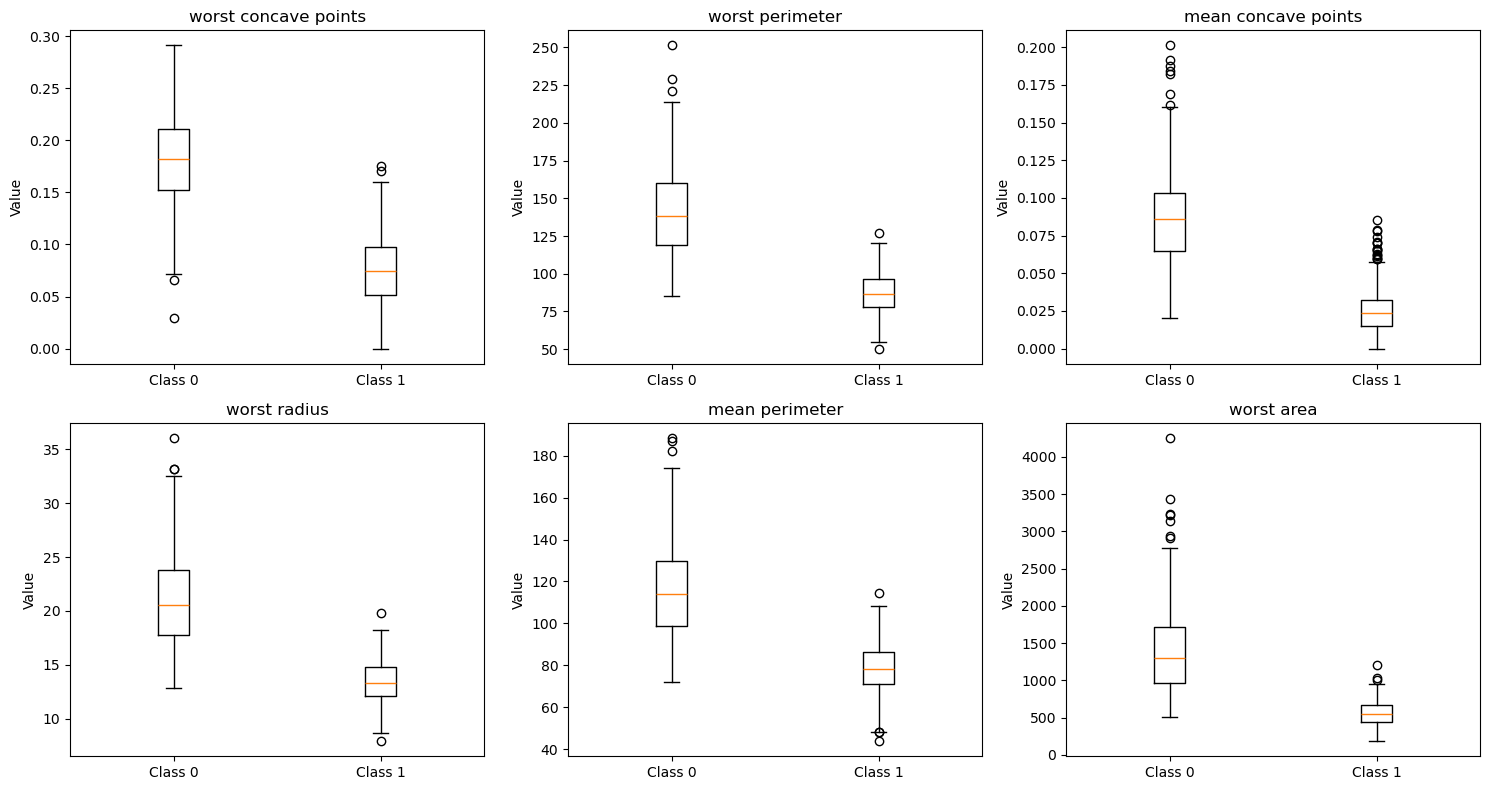

In [35]:
top_features = top_corr.index[:6]

fig, axes = plt.subplots(2, 3, figsize = (15, 8))

for ax, feature in zip(axes.ravel(), top_features):
    ax.boxplot(
        [
            df.loc[df['target'] == 0, feature],
            df.loc[df['target'] == 1, feature]
        ],
        labels = ['Class 0', 'Class 1']
    )

    ax.set_title(feature)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

### Insight:-
We need to scale the features but first we should split data because of **data leakage**

# 9. Train/Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 22,
    stratify = y
)
# I use stratify = y to keep the same percentage of classes in train and test data

In [38]:
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

print('\nTrain class distribution:')
print(np.bincount(y_train) / len(y_train))

print('\nTest class distribution:')
print(np.bincount(y_test) / len(y_test))

X_train: (455, 30)
X_test: (114, 30)

Train class distribution:
[0.37362637 0.62637363]

Test class distribution:
[0.36842105 0.63157895]


# 10. Baseline

In [41]:
majority_class = np.bincount(y_train).argmax()

y_baseline = np.full(
    shape = y_test.shape,
    fill_value = majority_class
)

print(f'Majority class: {majority_class}')
print(f'Baseline Accuracy: {accuracy_score(y_test, y_baseline)}')

Majority class: 1
Baseline Accuracy: 0.631578947368421


In [42]:
print(f'Baseline Precision: {precision_score(y_test, y_baseline)}')
print(f'Baseline Recall: {recall_score(y_test, y_baseline)}')
print(f'Baseline F1: {f1_score(y_test, y_baseline)}')

Baseline Precision: 0.631578947368421
Baseline Recall: 1.0
Baseline F1: 0.7741935483870968


# 11. Feature Scaling

In [43]:
scaler = MyStandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
print('Train mean:')
print(X_train_scaled.mean(axis = 0))

print('\nTrain std:')
print(X_train_scaled.std(axis = 0))

Train mean:
[-4.64561234e-15  1.41352131e-15  2.50422393e-15 -8.69390030e-16
  1.23473271e-14 -1.18586459e-16  9.82730381e-16  4.05231404e-16
 -4.66147267e-15  1.47867067e-15  1.18366855e-15 -1.25760208e-15
 -3.34286933e-16 -5.25220892e-16  1.04556168e-15 -4.13100567e-16
  1.15389993e-15  3.05860343e-16  1.32738753e-16  3.93580162e-16
 -2.39253062e-15 -5.56331538e-17  8.31599746e-16 -4.65988664e-16
  5.57649165e-15 -8.81590283e-16  5.56453540e-16 -2.99272207e-16
 -1.12535134e-15  4.90523373e-15]

Train std:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


# 12. Train My Model

In [71]:
model = LogisticRegression(
    learning_rate = 0.01,
    n_iterations = 5000,
    tolerance = 1e-7,
    verbose = True
)

model.fit(X_train_scaled, y_train)

Iteration    0 | Loss: 0.69
Iteration  100 | Loss: 0.24
Iteration  200 | Loss: 0.18
Iteration  300 | Loss: 0.15
Iteration  400 | Loss: 0.13
Iteration  500 | Loss: 0.12
Iteration  600 | Loss: 0.11
Iteration  700 | Loss: 0.11
Iteration  800 | Loss: 0.10
Iteration  900 | Loss: 0.10
Iteration 1000 | Loss: 0.09
Iteration 1100 | Loss: 0.09
Iteration 1200 | Loss: 0.09
Iteration 1300 | Loss: 0.09
Iteration 1400 | Loss: 0.08
Iteration 1500 | Loss: 0.08
Iteration 1600 | Loss: 0.08
Iteration 1700 | Loss: 0.08
Iteration 1800 | Loss: 0.08
Iteration 1900 | Loss: 0.08
Iteration 2000 | Loss: 0.08
Iteration 2100 | Loss: 0.07
Iteration 2200 | Loss: 0.07
Iteration 2300 | Loss: 0.07
Iteration 2400 | Loss: 0.07
Iteration 2500 | Loss: 0.07
Iteration 2600 | Loss: 0.07
Iteration 2700 | Loss: 0.07
Iteration 2800 | Loss: 0.07
Iteration 2900 | Loss: 0.07
Iteration 3000 | Loss: 0.07
Iteration 3100 | Loss: 0.07
Iteration 3200 | Loss: 0.07
Iteration 3300 | Loss: 0.07
Iteration 3400 | Loss: 0.07
Iteration 3500 | Los

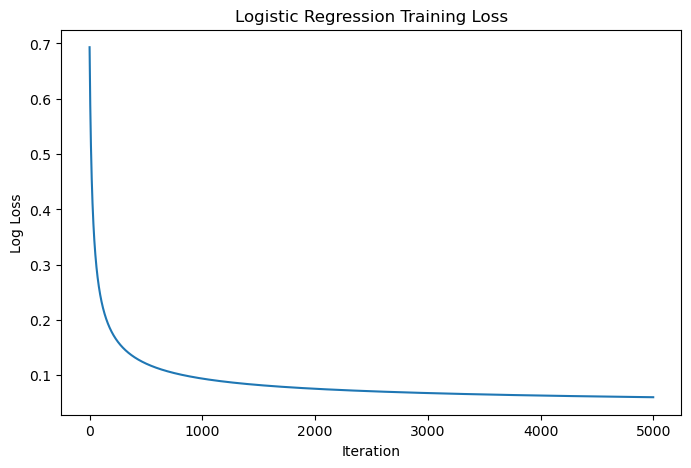

In [72]:
plt.figure(figsize = (8, 5))

plt.plot(model.cost_history)

plt.title('Logistic Regression Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Log Loss')

plt.show()

# 13. Predictions

In [73]:
y_proba = model.predict_proba(X_test_scaled)

print(y_proba[:10])

[6.28577942e-02 9.99866627e-01 2.08304560e-05 1.48712360e-03
 9.82238705e-01 9.81043131e-01 1.16643579e-02 9.98621977e-01
 9.99992624e-01 7.04464922e-01]


In [86]:
y_hat = model.predict(X_test_scaled)

print(y_hat[:10])

[0 1 0 0 1 1 0 1 1 1]


# 14. Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_hat)
precision = precision_score(y_test, y_hat)
recall = recall_score(y_test, y_hat)
f1 = f1_score(y_test, y_hat)
loss = log_loss(y_test, y_proba)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'Log Loss : {loss:.4f}')

Accuracy : 0.9474
Precision: 0.9459
Recall   : 0.9722
F1 Score : 0.9589
Log Loss : 0.1214


# 15. Confusion Matrix

In [88]:
cm = confusion_matrix(y_test, y_hat)
print(cm)

[[38  4]
 [ 2 70]]


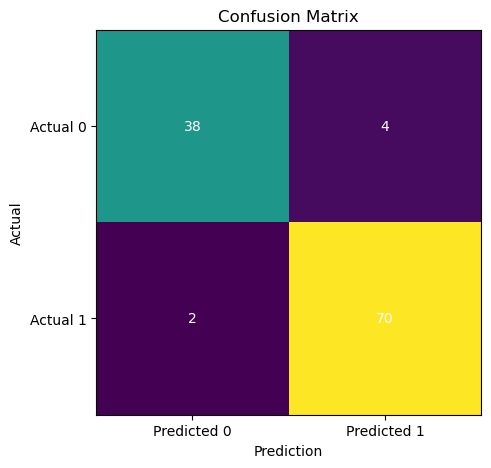

In [89]:
plt.figure(figsize = (6, 5))

plt.imshow(cm)

plt.xticks([0, 1], ['Predicted 0', 'Predicted 1'])
plt.yticks([0, 1], ['Actual 0', 'Actual 1'])

plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha = 'center', va = 'center', color = 'white')

plt.show()

# 16. Errors Understanding
- TN = 38
- TP = 70
- FN = 2
- FP = 4

We need to reduce the False-negative even if the False-positive increases

# 17. Threshold Analysis

In [55]:
thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for threshold in thresholds:
    predictions = (y_proba >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, predictions),
        "recall": recall_score(y_test, predictions),
        "f1": f1_score(y_test, predictions),
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1
0,0.1,0.900000,1.000000,0.947368
1,0.2,0.911392,1.000000,0.953642
2,0.3,0.922078,0.986111,0.953020
3,0.4,0.945946,0.972222,0.958904
4,0.5,0.945946,0.972222,0.958904
5,0.6,0.943662,0.930556,0.937063
6,0.7,0.943662,0.930556,0.937063
7,0.8,0.984615,0.888889,0.934307
8,0.9,1.000000,0.833333,0.909091


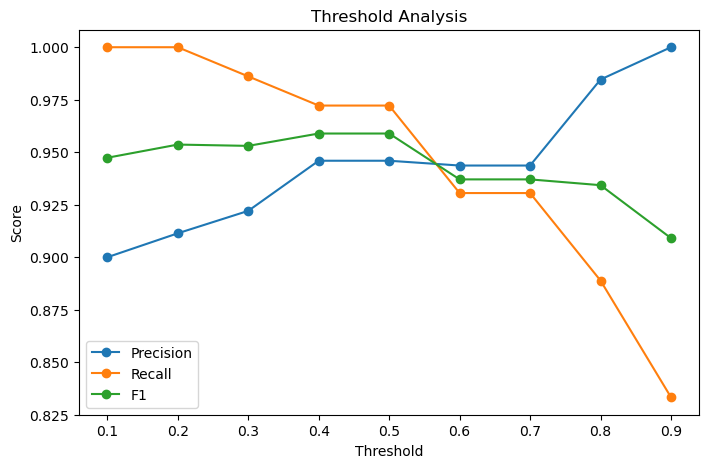

In [56]:
plt.figure(figsize = (8, 5))

plt.plot(
    threshold_results['threshold'],
    threshold_results['precision'],
    marker = 'o',
    label = 'Precision'
)

plt.plot(
    threshold_results['threshold'],
    threshold_results['recall'],
    marker = 'o',
    label = 'Recall'
)

plt.plot(
    threshold_results['threshold'],
    threshold_results['f1'],
    marker = 'o',
    label = 'F1'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Analysis')

plt.legend()
plt.show()

# 18. Choosing optimal threshold

In [104]:
y_hat = model.predict(X_test_scaled, threshold = 0.3)

print(y_hat[:10])

[0 1 0 0 1 1 0 1 1 1]


In [105]:
accuracy = accuracy_score(y_test, y_hat)
precision = precision_score(y_test, y_hat)
recall = recall_score(y_test, y_hat)
f1 = f1_score(y_test, y_hat)
loss = log_loss(y_test, y_proba)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1 Score : {f1:.4f}')
print(f'Log Loss : {loss:.4f}')

Accuracy : 0.9386
Precision: 0.9221
Recall   : 0.9861
F1 Score : 0.9530
Log Loss : 0.1214


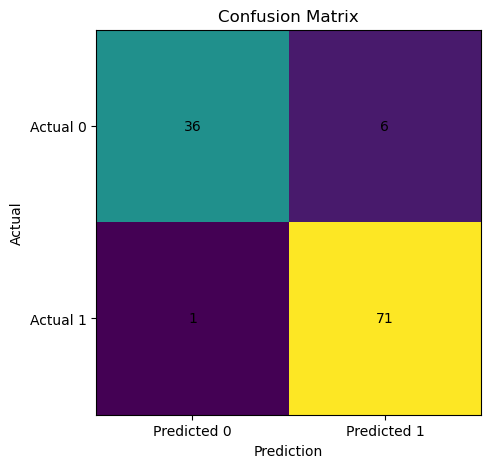

In [106]:
cm = confusion_matrix(y_test, y_hat)

plt.figure(figsize = (6, 5))

plt.imshow(cm)

plt.xticks([0, 1], ['Predicted 0', 'Predicted 1'])
plt.yticks([0, 1], ['Actual 0', 'Actual 1'])

plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha = 'center', va = 'center')

plt.show()

# 19. Error Analysis

In [107]:
errors = np.where(y_hat != y_test)[0]

print("Number of errors:", len(errors))
print("Error indices:", errors)

Number of errors: 7
Error indices: [  9  27  43  62  86  88 105]


In [108]:
error_analysis = pd.DataFrame({
    "actual": y_test[errors],
    "predicted": y_hat[errors],
    "probability": y_proba[errors]
})

error_analysis

,actual,predicted,probability
0,0,1,0.704465
1,1,0,0.282834
2,0,1,0.724576
3,0,1,0.763691
4,0,1,0.370625
5,0,1,0.851341
6,0,1,0.314421


# 20. Sklearn Benchmark

In [102]:
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

sk_model = SklearnLogisticRegression(max_iter = 5000, random_state = 22)

sk_model.fit(X_train_scaled, y_train)

sk_pred = sk_model.predict(X_test_scaled)
sk_proba = sk_model.predict_proba(X_test_scaled)[:, 1]

In [103]:
print(f'Accuracy : {accuracy_score(y_test, sk_pred):.4f}')
print(f'Precision: {precision_score(y_test, sk_pred):.4f}')
print(f'Recall   : {recall_score(y_test, sk_pred):.4f}')
print(f'F1 Score : {f1_score(y_test, sk_pred):.4f}')
print(f'Log Loss : {log_loss(y_test, sk_proba):.4f}')

Accuracy : 0.9474
Precision: 0.9583
Recall   : 0.9583
F1 Score : 0.9583
Log Loss : 0.1172


# 21. Final Interpretation

The custom Logistic Regression model achieved strong classification performance on the test set and clearly outperformed the majority-class baseline. The results show that the model was able to distinguish between benign and malignant cases with a good balance between precision and recall.

Accuracy alone, however, does not provide enough information about the model's performance. Since false negatives represent malignant cases incorrectly classified as benign, recall is particularly important in this problem. For this reason, threshold selection was treated as a decision rather than simply using the default value of 0.5.

At a threshold of 0.5, the model achieved 94.74% accuracy, 94.59% precision, 97.22% recall, and 95.88% F1 score, with 2 false negatives. Lowering the threshold to 0.3 increased recall to 98.61% and reduced false negatives to only 1 case, while increasing false positives from 4 to 6. Although this resulted in a small decrease in accuracy, precision, and F1 score, the 0.3 threshold was selected to prioritize recall and reduce the risk of missing malignant cases.

The custom implementation produced results close to the sklearn reference implementation, providing evidence that the underlying optimization, prediction, and evaluation logic is working correctly.

Overall, this experiment demonstrates that model evaluation should go beyond a single performance metric. The appropriate threshold and model should be selected based on the consequences of different types of errors and the objective of the application.